# Prepare SGKAN Algorithm

## New Algorithm Steps

1. **SWIM Sampling:** Calculate multi-dimensional SWIM probabilities from the training set (score each candidate pair by |Δy|inf / ||Δx||, using full-D distance). Sample one data pair (x_a, x_b) per neuron (q) in the hidden layer using computed probabilities.

2. **1D projection per input dimension:** For each selected pair (for neuron q) and each input dimension p, project the pair onto that single dimension to get an interval [lo, hi], where lo = min(x_a[p], x_b[p]) and hi = max(x_a[p], x_b[p]). This interval defines the local region that edge (q, p) will specialize in.

3. **Collect local 1D points:** Collect the training points whose p-th coordinate falls inside [lo, hi]. This gives a local subset of (x_p, y) pairs, i.e., purely 1D x-values (not the full D-dimensional vectors) paired with their target y. If too few points fall inside (below `min_points`), fall back to the k nearest neighbors around the midpoint instead; if too many fall inside (above `max_points`), select random `max_points` points between [lo, hi]. So, this approach will try to keep every edge local and computationally bounded.

4. **Select inducing points + lengthscale (Kernel Regression, GP-like, but gradient-free):** From this local 1D subset, select a fixed number (`num_inducing`) of representative points z_1, ..., z_k as inducing points, and set the kernel lengthscale via the `(hi - lo) * sigma_scale `. Both steps use only the local x-values (without y), so this stays fully data-driven but target-independent. Here, I didn't fit a 1D GP because even a single 1D GP still requires gradient-descent-based hyperparameter optimization (length scale, noise variance, signal variance), and the more neurons, the more processing time.

5. **Build the kernel matrix:** Evaluate a GP-like kernel function (RBF, Matérn, or periodic) between the local points and the inducing points, producing a (local_n, num_inducing) feature matrix for each edge q,p.

6. **Fit this edge on its own local target:** Solve a Ridge regression using this local kernel-feature matrix as input and the local y-values as the target. This gives edge-specific coefficients w_1, ..., w_k. This is a closed-form linear solve, not an iterative optimization.

7. **Learning:**
   1. **Evaluate the fitted edge (univariate function):** For any x_p (seen in training or not), the per edge's output is φ_q,p(x_p) = Σ_j w_j · k(x_p, z_j), so φ_q,p is a one-dimensional (univariate) function, matching the KAN requirement that each edge depend on a single input variable.
   2. **Combine the D edges of neuron q:** Evaluate all D edges of neuron q (one per input dimension) on the full training set, stack their outputs into an (N, D) matrix, and fit a second Ridge regression against the full training target y. This gives the neuron-level ("h-function") weights and bias, and is again a closed-form solve.

8. **Layer output:** Repeat steps 1–7 for every neuron q = 1, ..., layer_width to get the full hidden layer output matrix H (N, layer_width).

9.  **Stack layers:** Treat H as the input to the next layer and repeat steps 1–8.

## Step 0: Import required libraries

In [1]:
import sys
import os
# Add the parent directory to Python's module search path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

import swim as ss

## Step 1: Load datasets

In [2]:
def load_dataset(dataset_prefix: str):
    # base data directory
    DATA_DIR = os.path.join(os.getcwd(), "..", "data")
    # load train and test set
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    # slice train and test set
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test


In [3]:
# load tf1 dataset as an example
tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = load_dataset("tf1")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = load_dataset("tf2")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = load_dataset("tf4")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = load_dataset("tf5")

x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (3750, 10)
y_train shape: (3750,)
x_test shape: (1250, 10)
y_test shape: (1250,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)


## Step 2: Perform SWIM Sampling

In [4]:
random_seed = 0
# 1. Generate M candidate pairs using full-D distance (multi-dimensional)
x_a, x_b, y_a, y_b = ss.sample_candidate_pairs(tf1_x_train, tf1_y_train, random_seed=random_seed)
# 2) score each candidate pair: |dy| / ||dx|| (full-D distance)
probs = ss.create_swim_probabilities(x_a, x_b, y_a, y_b)
# 3) Sample pairs for each neuron (q) in the hidden layer
layer_width = 3
x_a_sel, x_b_sel, y_a_sel, y_b_sel, selected_idx = ss.select_pairs(
    x_a, x_b, y_a, y_b, probs, layer_width=layer_width, random_seed=random_seed
)
print("x_a_sel shape:", x_a_sel.shape)
print("x_b_sel shape:", x_b_sel.shape)

x_a_sel shape: (3, 2)
x_b_sel shape: (3, 2)


In [5]:
def select_swim_pairs_gen(X, y, layer_width, random_seed):
    # 1. Generate M candidate pairs using full-D distance (multi-dimensional)
    x_a, x_b, y_a, y_b = ss.sample_candidate_pairs(X, y, random_seed=random_seed)
    # 2) score each candidate pair: |dy|_inf / ||dx|| (full-D distance)
    probs = ss.create_swim_probabilities(x_a, x_b, y_a, y_b)
    # 3) Sample pairs for each neuron (q) in the hidden layer
    x_a_sel, x_b_sel, y_a_sel, y_b_sel, _ = ss.select_pairs(
        x_a, x_b, y_a, y_b, probs, layer_width=layer_width, random_seed=random_seed
    )
    return x_a_sel, x_b_sel, y_a_sel, y_b_sel


## Step 3: Collect local 1D points

1. Project each pair onto the one-dimensional [lo, hi] interval, where lo = min(x_a1, x_b1) and hi = max(x_a1, x_b1)
2. Collect the 1D training point values that fall inside the [lo, hi] interval

- `min_points`: minimum number of points required inside the interval; below this, fall back to k nearest neighbors instead of trusting a too-sparse interval.
- `max_points`: caps how many interval points are used, keeping the edge computationally cheap even when the interval covers most of the data.

In [6]:
# Project sampled SWIM pair to 1D and collect local points
def collect_local_gen(X, y, p, lo, hi, min_points=5, max_points=1000, k_fallback=15, cap_seed=0):
    # Take the values of feature p
    x_p = X[:, p]
    # Collect the points that fall inside the interval
    mask = (x_p >= lo) & (x_p <= hi)
    n_inside = int(mask.sum())
    
    # print(f"Number of inside points: {n_inside}, train set size: {X.shape[0]}")
    
    # Center of the interval
    midpoint = (lo + hi) / 2
    # If there are enough points inside the interval
    if n_inside >= min_points:
        x_inside, y_inside = x_p[mask], y[mask]
        # If there are too many points inside, keep only the ones closest to the midpoint
        if n_inside <= max_points:
            return x_inside, y_inside, "interval"
        # Take random max_points from the interval
        rng = np.random.default_rng(cap_seed)
        cap_idx = rng.choice(n_inside, size=max_points, replace=False)
        return x_inside[cap_idx], y_inside[cap_idx], "interval_capped"
    # Otherwise there are too few points inside the interval
    else:
        # Take the nearest points around the midpoint instead
        order = np.argsort(np.abs(x_p - midpoint))
        knn_idx = order[:k_fallback]
        return x_p[knn_idx], y[knn_idx], "knn_fallback"
    
# For quick testing q = 0, p = 0
q, p = 0, 0
lo = min(x_a_sel[q, p], x_b_sel[q, p])
hi = max(x_a_sel[q, p], x_b_sel[q, p])

local_x_p, local_y, method = collect_local_gen(tf1_x_train, tf1_y_train, p, lo, hi)
print(f"method={method}, local_x_p shape={local_x_p.shape}, local_y shape={local_y.shape}")

method=interval_capped, local_x_p shape=(1000,), local_y shape=(1000,)


## Step 4: Kernel Matrix Construction — Select inducing points + calculate data-driven lengthscale values for each edge

Fitting a traditional GP surrogate requires solving a gradient-descent optimization problem to find the optimal `lengthscale`, `noise variance`, and `signal variance`. Since the aim of this work is to find a data-driven, smart-sampling approach for fitting a KAN without gradient descent, fitting a local GP surrogate in the traditional way would still involve a gradient-descent optimization step. Therefore, I use kernel matrix constructionfunctions (RBF, periodic, Matérn, etc.) directly, without fitting their hyperparameters via gradient descent.

1. Select a fixed number (`num_inducing`) of representative points. This fixes the number of representative points used to build the kernel features, keeping each edge's capacity constant.
2. Use the interval width to set the lengthscale empirically from the training data, instead of using gradient descent to find it.

In [7]:
def rbf_kernel(x1, x2, l_p):
    """RBF function"""
    r2 = (x1[:, None] - x2[None, :]) ** 2
    return np.exp(-r2 / (2 * l_p ** 2))


def matern_kernel(x1, x2, l_p):
    """Matern nu=5/2"""
    r = np.abs(x1[:, None] - x2[None, :]) / l_p
    sqrt5_r = np.sqrt(5) * r
    return (1 + sqrt5_r + (5 / 3) * r ** 2) * np.exp(-sqrt5_r)


def periodic_kernel(x1, x2, l_p, period=1.0):
    """ExpSineSquared"""
    r = np.abs(x1[:, None] - x2[None, :])
    return np.exp(-2 * np.sin(np.pi * r / period) ** 2 / (l_p ** 2))


def apply_kernel(x1, x2, l_p, kernel_type="rbf", period=1.0):
    # Routes to the selected kernel function
    if kernel_type == "rbf":
        return rbf_kernel(x1, x2, l_p)
    elif kernel_type == "matern":
        return matern_kernel(x1, x2, l_p)
    elif kernel_type == "periodic":
        return periodic_kernel(x1, x2, l_p, period=period)
    else:
        raise ValueError(f"Unknown kernel_type: {kernel_type}")


# Kernel matrix creation
def build_edge_features(local_x_p, lo, hi, num_inducing=15, sigma_scale=1.0, seed=0,
    kernel_type="rbf", period=1.0):

    n = local_x_p.shape[0]
    n_ind = min(num_inducing, n)

    # Randomly select a fixed number of inducing (representative) points from the local data
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=n_ind, replace=False)
    z_p = np.sort(local_x_p[idx])

    # Lengthscale derived directly from the SWIM-selected interval width,
    l_p = sigma_scale * (hi - lo)
    l_p = max(l_p, 1e-6)  # guard against degenerate (near-zero-width) intervals

    # Evaluate the kernel between every training point and the inducing points
    k_local = apply_kernel(local_x_p, z_p, l_p, kernel_type=kernel_type, period=period)

    return k_local, z_p, l_p

# Quick test
k_feat_test, z_test, l_test = build_edge_features(local_x_p, lo, hi, num_inducing=15, seed=random_seed)
print("k_feat_test shape:", k_feat_test.shape)
print("z_test shape:", z_test.shape) # inducing points
print("lengthscale:", round(l_test, 5))

k_feat_test shape: (1000, 15)
z_test shape: (15,)
lengthscale: 0.29333


## Step 5: 2 Ridge Regression: one for per edge, one for neuron

In [8]:
def fit_layer(
    X, y, layer_width, pair_selection_strategy="swim", num_inducing=15,
    sigma_scale=1.0, alpha_edge=1e-3, alpha_neuron=1e-3,
    seed=0, kernel_type="rbf", period=1.0, max_local_points=1000):

    # Number of data points and features
    N, D_in = X.shape[0], X.shape[1]

    # Algorithm 1: Adapting SWIM to Per-Dimension Intervals
    # For benchmarking purposes: put random sampling condition for comparison
    # Select data pairs using swim or random
    if pair_selection_strategy == "swim":
        x_a, x_b, y_a, y_b = select_swim_pairs_gen(X, y, layer_width, random_seed=seed)
    elif pair_selection_strategy == "random": # sample pairs randomly without swim
        x_a, x_b, y_a, y_b = ss.sample_candidate_pairs(X, y, layer_width, random_seed=seed)
    else:
        raise ValueError("please select pair_selection method as swim or random")
    print(f"[fit_layer] pair_selection_strategy = '{pair_selection_strategy}' "
          f"(layer_width={layer_width}, D_in={D_in})")
    

    # Create an empty hidden layer output matrix H
    H = np.zeros((N, layer_width))
    neurons = []
    method_counts = Counter()

    for q in range(layer_width):
        edge_outputs, edge_params = [], []
        for p in range(D_in):
            # Create swim projection interval bounds
            lo = min(x_a[q, p], x_b[q, p])
            hi = max(x_a[q, p], x_b[q, p])
            
            # Algorithm 2: Local Point Collection
            local_x_p, local_y, method = collect_local_gen(
                X, y, p, lo, hi, max_points=max_local_points,
                cap_seed=seed + q * D_in + p
            )
            method_counts[method] += 1

            # Algorithm 3: Building the Edge Kernel Matrix
            # Pick inducing points z_p from the local subset (x-only, no y)
            # Compute kernel matrix using collected local and inducing points
            k_local, z_p, l_p = build_edge_features(
                local_x_p, lo, hi, num_inducing=num_inducing,
                sigma_scale=sigma_scale, seed=seed + q, kernel_type=kernel_type,
                period=period)

            # Algorithm 4: Edge-level Ridge Regression
            edge_model = Ridge(alpha=alpha_edge, fit_intercept=False)
            edge_model.fit(k_local, local_y)
            w_p = edge_model.coef_

            # Evaluate this edge on the full training set, using the SAME l_p as fit
            # Kernel similarity between points and the fixed inducing points
            k_train = apply_kernel(X[:, p], z_p, l_p, kernel_type=kernel_type, period=period)
            # Weighted sum -> this edge's output for each query point
            # Store fixed paramaters to use it later
            edge_outputs.append(k_train @ w_p)
            edge_params.append({"z_p": z_p, "l_p": l_p, "w_p": w_p, "local_y": local_y, "lo": lo, "hi": hi})

        # Algorithm 5: Neuron Construction
        # (N, D_in) -- one column per edge output, each column denotes one edge result
        edge_outputs = np.column_stack(edge_outputs)

        neuron_model = Ridge(alpha=alpha_neuron, fit_intercept=True)
        neuron_model.fit(edge_outputs, y)
        H[:, q] = neuron_model.predict(edge_outputs)

        neurons.append({
            "edge_params": edge_params,
            "neuron_w": neuron_model.coef_, "bias": neuron_model.intercept_,
            "kernel_type": kernel_type, "period": period,
        })

    # Observe local point collection methods distribution
    total_edges = layer_width * D_in
    print(f"[fit_layer] local-window method counts over {total_edges} edges: "
          f"{dict(method_counts)}")
    return H, neurons


## Step 6: Transform Layer

In [9]:
def transform_layer(X_new, neurons):

    # Number of new samples and number of neurons in this layer
    N_new = X_new.shape[0]
    layer_width = len(neurons)
    H_new = np.zeros((N_new, layer_width))

    # Apply each already-fitted neuron to the new data (no refitting here)
    for q, neuron in enumerate(neurons):
        edge_outputs = []
        for p, ep in enumerate(neuron["edge_params"]):
            # Recompute this edge's output on X_new, using the stored (fixed) z_p, l_p, w_p
            # Kernel similarity between query points and the fixed inducing points from training
            k = apply_kernel(X_new[:, p], ep["z_p"], ep["l_p"],
                              kernel_type=neuron["kernel_type"], period=neuron["period"])
            # Weighted sum -> this edge's output for each query point
            edge_outputs.append(k @ ep["w_p"])
        edge_outputs = np.column_stack(edge_outputs)

        # Apply the stored neuron-level (stage 2) weights and bias
        H_new[:, q] = edge_outputs @ neuron["neuron_w"] + neuron["bias"]

    return H_new

## Step 7: TF1 - First layer results

In [10]:
layer_width_1 = 750
num_inducing = 30
alpha_edge = 1e-3
alpha_neuron = 1e-3
kernel_type = "rbf"

H1, neurons1 = fit_layer(
    tf1_x_train, tf1_y_train, layer_width_1,
    num_inducing=num_inducing, alpha_edge=alpha_edge,
    alpha_neuron=alpha_neuron, seed=random_seed, kernel_type=kernel_type)

print("H1 shape:", H1.shape)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=750, D_in=2)
[fit_layer] local-window method counts over 1500 edges: {'interval_capped': 898, 'interval': 602}
H1 shape: (5000, 750)


In [11]:
len(neurons1)

750

In [12]:
# Quick test: First neuron dictionary
neurons1[0]["edge_params"]

[{'z_p': array([0.2137787 , 0.22548932, 0.22805506, 0.2325156 , 0.23325962,
         0.25257424, 0.28975701, 0.29585712, 0.30685996, 0.31310755,
         0.31572192, 0.32582993, 0.34467662, 0.34621137, 0.3472281 ,
         0.35768977, 0.39375629, 0.41403521, 0.42850058, 0.4318    ,
         0.43602462, 0.44256571, 0.44699981, 0.46169665, 0.47206386,
         0.47674916, 0.47854869, 0.47867915, 0.4854705 , 0.4905274 ]),
  'l_p': 0.293328764432502,
  'w_p': array([ 0.28587493,  0.2802697 ,  0.27705319,  0.26984477,  0.26844738,
          0.2142859 ,  0.03744186,  0.00312927, -0.05990263, -0.09565767,
         -0.11048386, -0.16636443, -0.25953764, -0.26622269, -0.27056088,
         -0.3105753 , -0.36262288, -0.31472599, -0.23918991, -0.21676062,
         -0.18512278, -0.12954851, -0.08724138,  0.08039492,  0.22444627,
          0.2966242 ,  0.3255193 ,  0.32763933,  0.44272456,  0.53441547]),
  'local_y': array([0.50011159, 0.51009537, 0.67496355, 0.49997315, 0.57919474,
         0.53740

## Step 8: Visualize an example edge

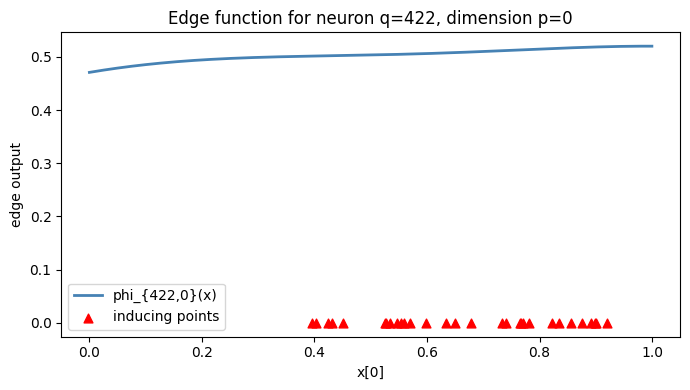

In [13]:
# Pick a specific neuron and dimension to inspect
q_example, p_example = np.random.randint(layer_width_1), np.random.randint(tf1_x_train.shape[1])
q_example = 422
p_example= 0
# take random neuron q
neuron = neurons1[q_example]
# take the edge parameters for random dimension p
edge_p = neuron["edge_params"][p_example]
z_p = edge_p["z_p"]
l_p = edge_p["l_p"]
w_p = edge_p["w_p"]

# Evaluate the fitted edge function on a dense grid over the actual data range
x_dense = np.linspace(tf1_x_train[:, p_example].min(), tf1_x_train[:, p_example].max(), 200)
edge_curve = apply_kernel(x_dense, z_p, l_p, kernel_type=neuron["kernel_type"], period=neuron["period"]) @ w_p

plt.figure(figsize=(7, 4))
plt.plot(x_dense, edge_curve, color="steelblue", lw=2, label=f"phi_{{{q_example},{p_example}}}(x)")
plt.scatter(z_p, np.zeros_like(z_p), color="red", marker="^", s=40, label="inducing points")
plt.xlabel(f"x[{p_example}]")
plt.ylabel("edge output")
plt.title(f"Edge function for neuron q={q_example}, dimension p={p_example}")
plt.legend()
plt.tight_layout()
plt.show()

## Step 9: Stack Layers

In [14]:
layer_width_2 = 1
num_inducing = 30
alpha_edge = 1e-3
alpha_neuron = 1e-3
kernel_type = "rbf"

H2, neurons2 = fit_layer(
    H1, tf1_y_train, layer_width_2,
    num_inducing=num_inducing, alpha_edge=alpha_edge, alpha_neuron=alpha_neuron,
    kernel_type=kernel_type, seed=random_seed) 
print("H2 shape:", H2.shape)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval': 213, 'interval_capped': 536, 'knn_fallback': 1}
H2 shape: (5000, 1)


In [15]:
y_pred_final = H2[:, 0]

rmse_final = np.sqrt(np.mean((y_pred_final - tf1_y_train) ** 2))
print(f"2 layer SGKAN RMSE (training set): {rmse_final:.8f}")
print(f"y_train std: {tf1_y_train.std():.5f}")

2 layer SGKAN RMSE (training set): 0.00021628
y_train std: 0.16632


## Step 10: TF1 Test Set Result

In [16]:
H1_test = transform_layer(tf1_x_test, neurons1)
H2_test = transform_layer(H1_test, neurons2)
y_pred_test = H2_test[:, 0]

rmse_test = np.sqrt(np.mean((y_pred_test - tf1_y_test) ** 2))
print(f"2 layer SGKAN RMSE (test set): {rmse_test:.8f}")
print(f"y_test std: {tf1_y_test.mean():.5f}")

2 layer SGKAN RMSE (test set): 0.00028472
y_test std: 0.50000
